In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using text column: review
Using label column: sentiment
Label classes: ['negative', 'positive']

=== Accuracies (60/20/20) ===
Train:       0.7846
Validation:  0.7515
Test:        0.7574


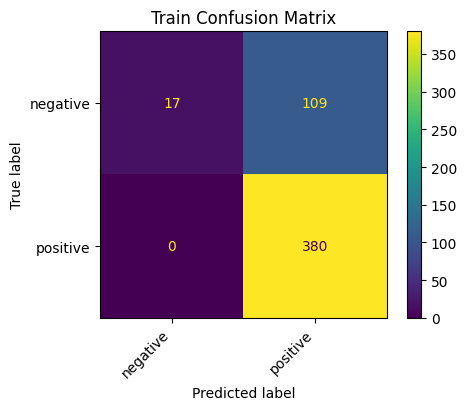

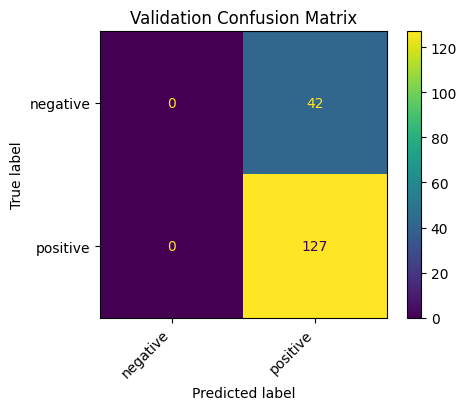

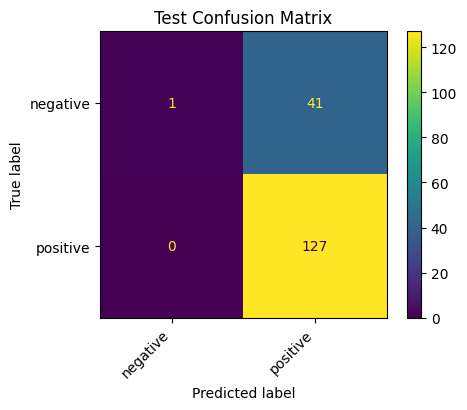


=== Classification Report: Train ===
              precision    recall  f1-score   support

    negative       1.00      0.13      0.24       126
    positive       0.78      1.00      0.87       380

    accuracy                           0.78       506
   macro avg       0.89      0.57      0.56       506
weighted avg       0.83      0.78      0.72       506

=== Classification Report: Validation ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        42
    positive       0.75      1.00      0.86       127

    accuracy                           0.75       169
   macro avg       0.38      0.50      0.43       169
weighted avg       0.56      0.75      0.64       169

=== Classification Report: Test ===
              precision    recall  f1-score   support

    negative       1.00      0.02      0.05        42
    positive       0.76      1.00      0.86       127

    accuracy                           0.76       169
   macro avg

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# --- Naive Bayes Sentiment (60:20:20) on Google Colab ---

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# ===== 1) Load data =====
# If your file is elsewhere (e.g., in Drive), change this path accordingly.
file_path = "/content/ev2_bikewale_with_sentiment_V3.csv"
df = pd.read_csv(file_path).dropna(how="all").copy()

# ===== 2) Pick text & label columns =====
# Prefer common names; fall back to a heuristic if needed.
def guess_text_and_label_columns(df: pd.DataFrame):
    likely_text = ["review", "text", "comment", "content", "message", "feedback", "description", "body", "summary"]
    likely_label = ["sentiment", "label", "polarity", "target", "class", "rating"]
    text_col = next((c for c in df.columns if c.lower() in likely_text), None)
    label_col = next((c for c in df.columns if c.lower() in likely_label), None)

    if text_col is None:
        # Heuristic: longest avg string column
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        if obj_cols:
            text_col = max(obj_cols, key=lambda c: df[c].dropna().astype(str).map(len).mean())

    if label_col is None:
        # Heuristic: column with few unique values (<=5)
        candidates = [(c, df[c].nunique(dropna=True)) for c in df.columns]
        small = [c for c, n in candidates if n <= 5]
        label_col = small[0] if small else df.columns[-1]

    return text_col, label_col

text_col, label_col = guess_text_and_label_columns(df)
print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

# Keep only those columns and basic clean
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

work_df = df[[text_col, label_col]].dropna().copy()
work_df[text_col] = work_df[text_col].map(clean_text)

# ===== 3) Encode labels =====
le = LabelEncoder()
y = le.fit_transform(work_df[label_col])
X_text = work_df[text_col].values
classes = list(le.classes_)
print("Label classes:", classes)

# ===== 4) 60/20/20 split (stratified) =====
# First: train 60% vs temp 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.40, random_state=42, stratify=y
)
# Then: split temp into val 20% and test 20% (half-half of remaining 40%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# ===== 5) Vectorize text (fit on train only) =====
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

# ===== 6) Train Multinomial Naive Bayes =====
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# ===== 7) Predictions & Accuracies =====
def acc(y_true, y_pred):
    return round(accuracy_score(y_true, y_pred), 4)

y_train_pred = model.predict(X_train_vec)
y_val_pred   = model.predict(X_val_vec)
y_test_pred  = model.predict(X_test_vec)

print("\n=== Accuracies (60/20/20) ===")
print(f"Train:       {acc(y_train, y_train_pred)}")
print(f"Validation:  {acc(y_val, y_val_pred)}")
print(f"Test:        {acc(y_test, y_test_pred)}")

# ===== 8) Confusion Matrices =====
def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

show_cm(y_train, y_train_pred, "Train Confusion Matrix")
show_cm(y_val, y_val_pred, "Validation Confusion Matrix")
show_cm(y_test, y_test_pred, "Test Confusion Matrix")

# ===== 9) Classification Reports =====
print("\n=== Classification Report: Train ===")
print(classification_report(y_train, y_train_pred, target_names=classes))
print("=== Classification Report: Validation ===")
print(classification_report(y_val, y_val_pred, target_names=classes))
print("=== Classification Report: Test ===")
print(classification_report(y_test, y_test_pred, target_names=classes))


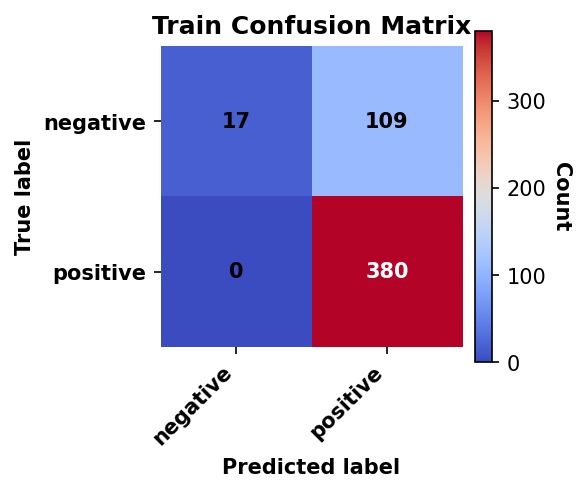

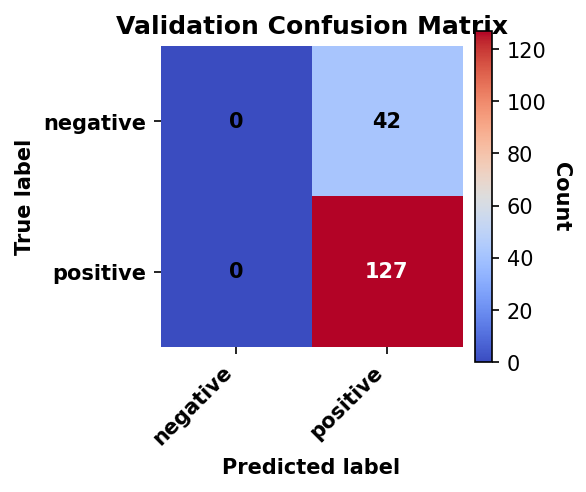

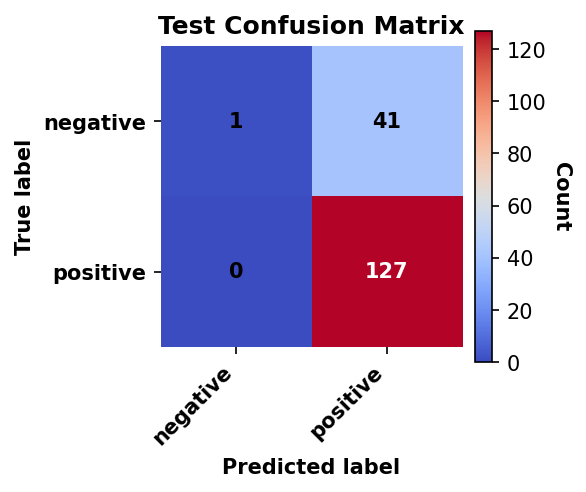

In [ ]:
# ===== 8) High-contrast Confusion Matrices (coolwarm + bold labels) =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def show_cm_high_contrast(y_true, y_pred, title, classes):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))

    fig, ax = plt.subplots(figsize=(4, 3.8), dpi=150)
    # coolwarm is diverging and high-contrast; set vmin/vmax for full range
    im = ax.imshow(cm, interpolation='nearest', cmap='coolwarm', vmin=0, vmax=cm.max() if cm.max() > 0 else 1)
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.ax.set_ylabel('Count', rotation=270, labelpad=12, fontweight='bold')

    # Tick labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontweight='bold')
    ax.set_yticklabels(classes, fontweight='bold')

    # Title and axis labels
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted label', fontweight='bold')
    ax.set_ylabel('True label', fontweight='bold')

    # Bold value labels with automatic contrast (white on dark, black on light)
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(
                j, i, f"{val:d}",
                ha="center", va="center",
                fontweight='bold',
                color="white" if val > thresh else "black"
            )

    # Cleaner look
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

# Call these instead of the old show_cm(...)
show_cm_high_contrast(y_train, y_train_pred, "Train Confusion Matrix", classes)
show_cm_high_contrast(y_val,   y_val_pred,   "Validation Confusion Matrix", classes)
show_cm_high_contrast(y_test,  y_test_pred,  "Test Confusion Matrix", classes)


Using text column: review
Using label column: sentiment
Classes: ['negative', 'positive']
Fitting 5 folds for each of 114 candidates, totalling 570 fits

Best CV Accuracy (Train only): 0.8696
Best Params: {'nb__alpha': 0.1, 'tfidf__analyzer': 'char_wb', 'tfidf__max_features': 30000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (3, 5), 'tfidf__strip_accents': 'unicode', 'tfidf__sublinear_tf': True}
Validation Accuracy: 0.858

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.71      0.71        42
    positive       0.91      0.91      0.91       127

    accuracy                           0.86       169
   macro avg       0.81      0.81      0.81       169
weighted avg       0.86      0.86      0.86       169


=== Final Test Accuracy (refit on Train+Val) ===
0.9053

Test Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.81      0.81        42
    positive      

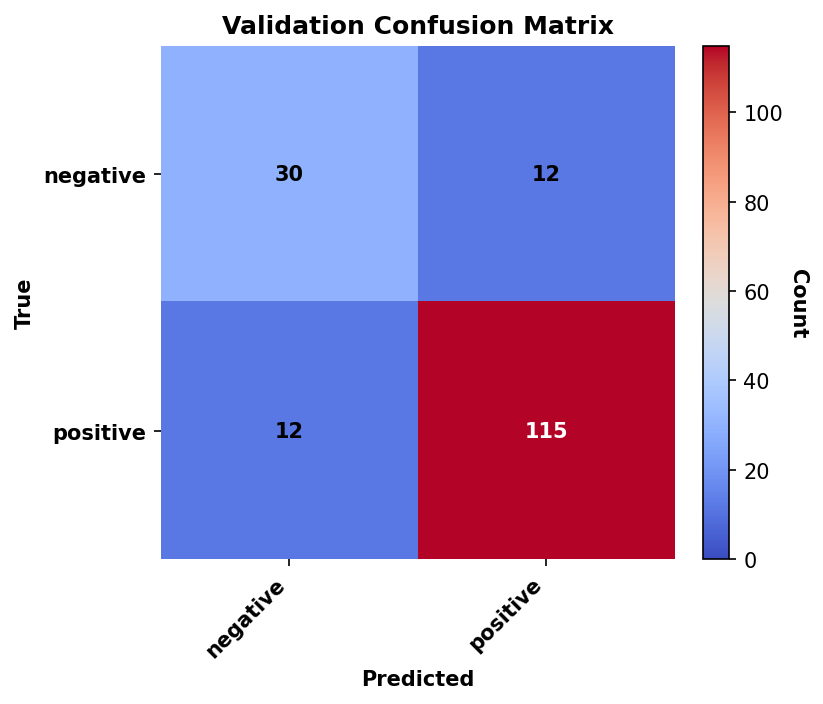

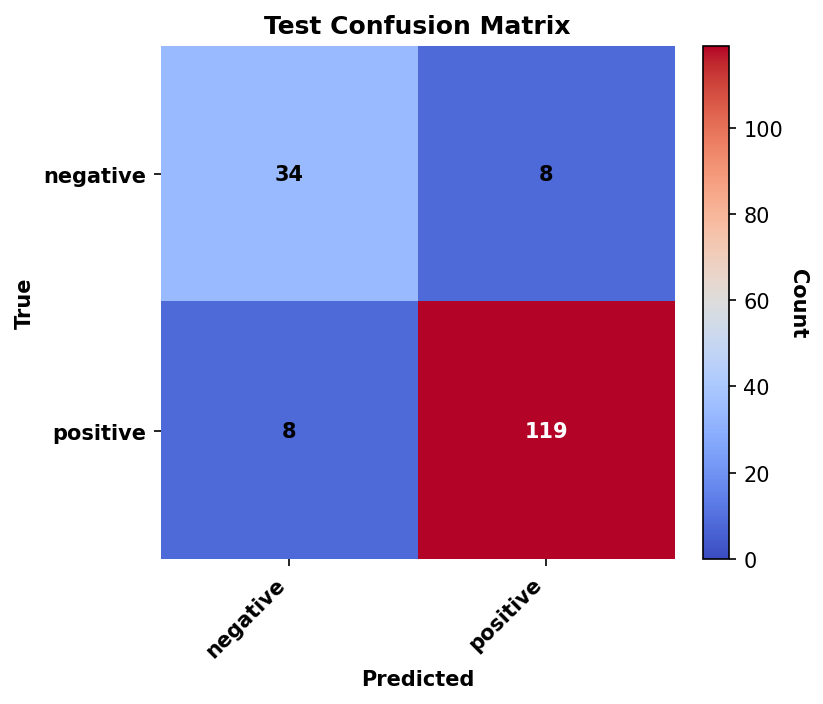

In [ ]:
# === Accuracy-boosted Naive Bayes for Sentiment (60:20:20) ===
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ---------- 1) Load ----------
file_path = "/content/ev2_bikewale_with_sentiment_V3.csv"
df = pd.read_csv(file_path).dropna(how="all").copy()

# ---------- 2) Pick text & label columns (same heuristic as before) ----------
def guess_text_and_label_columns(df: pd.DataFrame):
    likely_text = ["review","text","comment","content","message","feedback","description","body","summary"]
    likely_label = ["sentiment","label","polarity","target","class","rating"]
    text_col = next((c for c in df.columns if c.lower() in likely_text), None)
    label_col = next((c for c in df.columns if c.lower() in likely_label), None)
    if text_col is None:
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        if obj_cols:
            text_col = max(obj_cols, key=lambda c: df[c].dropna().astype(str).map(len).mean())
    if label_col is None:
        candidates = [(c, df[c].nunique(dropna=True)) for c in df.columns]
        small = [c for c, n in candidates if n <= 5]
        label_col = small[0] if small else df.columns[-1]
    return text_col, label_col

text_col, label_col = guess_text_and_label_columns(df)
print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

# ---------- 3) Light normalization + simple negation handling ----------
# - collapse spaces, lower, strip accents via vectorizer, join "not good" -> "not_good"
neg_re = re.compile(r"\b(?:no|not|never|n't)\s+(\w+)", flags=re.I)

def normalize_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    # simple handle for URLs, digits
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"\d+", " NUM ", s)
    # join negations to next token to preserve sentiment cue
    s = neg_re.sub(lambda m: "not_" + m.group(1), s)
    return s

work = df[[text_col, label_col]].dropna().copy()
work[text_col] = work[text_col].map(normalize_text)

# ---------- 4) Encode labels ----------
le = LabelEncoder()
y = le.fit_transform(work[label_col])
X = work[text_col].values
classes = list(le.classes_)
print("Classes:", classes)

# ---------- 5) 60/20/20 split (stratified) ----------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# ---------- 6) Pipelines & grid (vectorizer + NB alpha) ----------
# Two strong families:
#  A) Word n-grams (1–2/1–3), english stopwords, sublinear tf
#  B) Character n-grams (3–5) within word boundaries (great for misspellings/emoji/noise)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

param_grid = [
    # Word n-grams
    {
        "tfidf__analyzer": ["word"],
        "tfidf__ngram_range": [(1,2), (1,3)],
        "tfidf__min_df": [1,2,3],
        "tfidf__sublinear_tf": [True],
        "tfidf__stop_words": ["english"],
        "tfidf__strip_accents": ["unicode"],
        "tfidf__max_features": [30000, 50000, None],
        "nb__alpha": [0.05, 0.1, 0.3, 0.7, 1.0]
    },
    # Character n-grams
    {
        "tfidf__analyzer": ["char_wb"],
        "tfidf__ngram_range": [(3,5)],
        "tfidf__min_df": [2,3],
        "tfidf__sublinear_tf": [True],
        "tfidf__strip_accents": ["unicode"],
        "tfidf__max_features": [30000, 50000, None],
        "nb__alpha": [0.1, 0.3, 0.7, 1.0]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# ---------- 7) Tune on TRAIN only, evaluate on VAL ----------
gs.fit(X_train, y_train)
print("\nBest CV Accuracy (Train only):", round(gs.best_score_, 4))
print("Best Params:", gs.best_params_)

best_model = gs.best_estimator_
val_pred = best_model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", round(val_acc, 4))
print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred, target_names=classes))

# ---------- 8) Refit on Train+Val with best params, then Test ----------
X_trval = np.concatenate([X_train, X_val])
y_trval = np.concatenate([y_train, y_val])

best_model.fit(X_trval, y_trval)
test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print("\n=== Final Test Accuracy (refit on Train+Val) ===")
print(round(test_acc, 4))
print("\nTest Classification Report:")
print(classification_report(y_test, test_pred, target_names=classes))

# ---------- 9) High-contrast confusion matrices (coolwarm + bold) ----------
import numpy as np
def show_cm_high_contrast(y_true, y_pred, title, classes):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    fig, ax = plt.subplots(figsize=(6, 4.8), dpi=150)
    im = ax.imshow(cm, interpolation='nearest', cmap='coolwarm',
                   vmin=0, vmax=cm.max() if cm.max() > 0 else 1)
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.ax.set_ylabel('Count', rotation=270, labelpad=12, fontweight='bold')
    ax.set_xticks(np.arange(len(classes))); ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontweight='bold')
    ax.set_yticklabels(classes, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold'); ax.set_ylabel('True', fontweight='bold')
    thresh = cm.max()/2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j, i, f"{val:d}", ha='center', va='center', fontweight='bold',
                    color='white' if val > thresh else 'black')
    for s in ax.spines.values(): s.set_visible(False)
    plt.tight_layout(); plt.show()

show_cm_high_contrast(y_val,  val_pred,  "Validation Confusion Matrix", classes)
show_cm_high_contrast(y_test, test_pred, "Test Confusion Matrix", classes)


In [ ]:
# --- 5-fold Stratified CV: Naive Bayes Sentiment ---
import re, numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import make_scorer, accuracy_score, f1_score

file_path = "/content/ev2_bikewale_with_sentiment_V3.csv"
df = pd.read_csv(file_path).dropna(how="all").copy()

def guess_cols(df):
    txt_keys = ["review","text","comment","content","message","feedback","description","body","summary"]
    lab_keys = ["sentiment","label","polarity","target","class","rating"]
    text_col  = next((c for c in df.columns if c.lower() in txt_keys), None)
    label_col = next((c for c in df.columns if c.lower() in lab_keys), None)
    if text_col is None:
        obj = [c for c in df.columns if df[c].dtype=='object']
        if obj: text_col = max(obj, key=lambda c: df[c].dropna().astype(str).map(len).mean())
    if label_col is None:
        few = [c for c in df.columns if df[c].nunique(dropna=True) <= 5]
        label_col = few[0] if few else df.columns[-1]
    return text_col, label_col

text_col, label_col = guess_cols(df)

neg_re = re.compile(r"\b(?:no|not|never|n't)\s+(\w+)", flags=re.I)
def normalize_text(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"\d+", " NUM ", s)
    return neg_re.sub(lambda m: "not_" + m.group(1), s)

work = df[[text_col, label_col]].dropna().copy()
work[text_col] = work[text_col].map(normalize_text)

le = LabelEncoder()
y = le.fit_transform(work[label_col])
X = work[text_col].values
classes = list(le.classes_)
print("Classes:", classes)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,3),
        stop_words="english",
        strip_accents="unicode",
        sublinear_tf=True,
        min_df=2,
        max_features=50000
    )),
    ("nb", MultinomialNB(alpha=0.3))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro")
}
res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)

summary = pd.DataFrame({
    "Fold": np.arange(1,6),
    "Accuracy": res["test_accuracy"],
    "F1_macro": res["test_f1_macro"]
})
print("\nPer-fold results:\n", summary.round(4))
print("\nMean ± Std:")
print("Accuracy:", round(summary.Accuracy.mean(),4), "±", round(summary.Accuracy.std(ddof=1),4))
print("F1_macro:", round(summary.F1_macro.mean(),4), "±", round(summary.F1_macro.std(ddof=1),4))


Classes: ['negative', 'positive']

Per-fold results:
    Fold  Accuracy  F1_macro
0     1    0.8757    0.8128
1     2    0.8402    0.7228
2     3    0.8462    0.7366
3     4    0.8521    0.7500
4     5    0.8452    0.7362

Mean ± Std:
Accuracy: 0.8519 ± 0.014
F1_macro: 0.7517 ± 0.0355


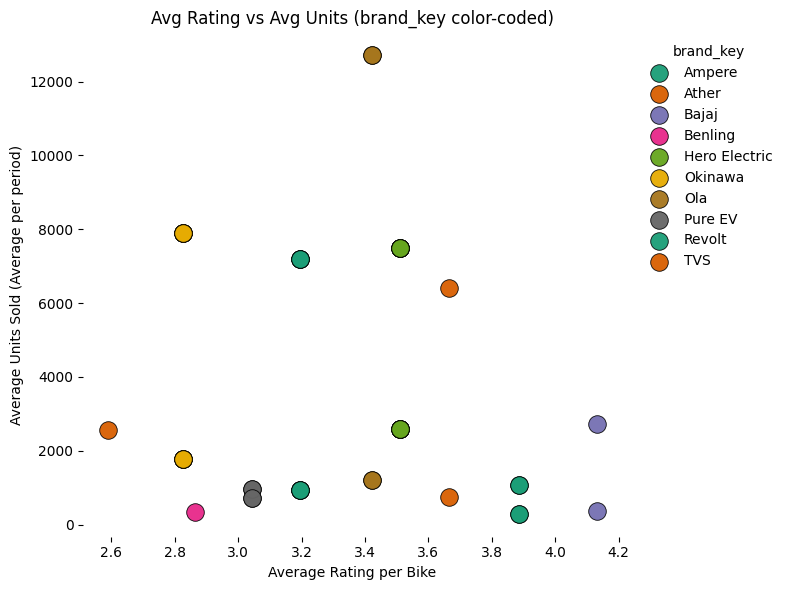

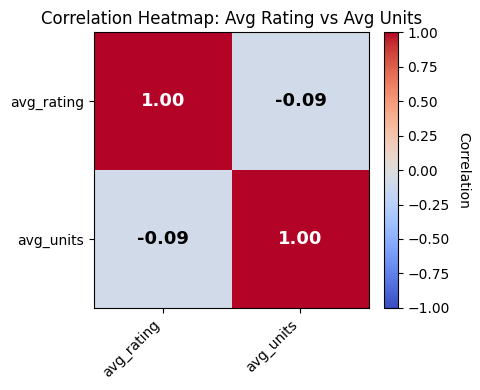

Saved to:
/content/scatter_avg_rating_vs_avg_units_dark_transparent.png
/content/heatmap_correlation_avg_rating_vs_avg_units.png


In [ ]:
# --- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- File paths (as you provided)
sales_path = "/content/EV2BikeWale_Sales_with_SalesDate_AND_brandkey.csv"
specs_path = "/content/EV_Models_Specs_Clean_India_NUMERIC.csv"
sent_path  = "/content/ev2_bikewale_with_sentiment_V3.csv"

# --- Load & clean
sales_df = pd.read_csv(sales_path)
specs_df = pd.read_csv(specs_path)
sent_df  = pd.read_csv(sent_path)

for df in (sales_df, specs_df, sent_df):
    df.columns = [c.strip().lower() for c in df.columns]

# --- Build model-level table: avg units per (brand_key, model), avg rating per brand_key
# sales has: brand_key, maker, num_vehicles ...
# specs has: brand_key, model name, price (inr) ...
sales_specs = sales_df.merge(
    specs_df[['brand_key','model name','price (inr)']],
    on='brand_key', how='left'
)

agg_sales = (sales_specs.groupby(['brand_key','model name','maker'], as_index=False)
             .agg(avg_units=('num_vehicles','mean')))

agg_rating = (sent_df.groupby('brand_key', as_index=False)
              .agg(avg_rating=('rating','mean')))

plot_df = (agg_sales.merge(agg_rating, on='brand_key', how='left')
           .dropna(subset=['avg_units','avg_rating'])
           .rename(columns={'model name':'model_name'}))

# Ensure string type for color grouping
plot_df['brand_key'] = plot_df['brand_key'].astype(str)

# =========================
# 1) SCATTER (Avg Rating vs Avg Units) — brand_key color-coded
# =========================
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)        # transparent figure
ax.set_facecolor('none')      # transparent axes

brands = sorted(plot_df['brand_key'].unique())
cmap = plt.get_cmap('Dark2')  # dark-theme friendly categorical palette
color_map = {b: cmap(i % cmap.N) for i, b in enumerate(brands)}

for b in brands:
    sub = plot_df[plot_df['brand_key'] == b]
    ax.scatter(
        sub['avg_rating'], sub['avg_units'],
        s=160, marker='o', alpha=0.95,
        edgecolors='black', linewidths=0.6,
        color=color_map[b], label=b
    )

ax.set_xlabel('Average Rating per Bike')
ax.set_ylabel('Average Units Sold (Average per period)')
ax.set_title('Avg Rating vs Avg Units (brand_key color-coded)')

# Legend outside for readability; no frame for clean look
ax.legend(title='brand_key', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Remove spines/grid to keep the “no background” look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig("/content/scatter_avg_rating_vs_avg_units_dark_transparent.png", dpi=240, transparent=True)
plt.show()

# =========================
# 2) CORRELATION HEATMAP (Avg Rating vs Avg Units)
# =========================
corr_df = plot_df[['avg_rating','avg_units']].copy()
corr_matrix = corr_df.corr()  # Pearson by default

fig2, ax2 = plt.subplots(figsize=(5,4))
im = ax2.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

# Colorbar
cbar = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Correlation', rotation=270, labelpad=15)

# Axis ticks/labels
ax2.set_xticks(range(corr_matrix.shape[1]))
ax2.set_yticks(range(corr_matrix.shape[0]))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax2.set_yticklabels(corr_matrix.index)

# Bold value labels with dynamic contrast
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax2.text(j, i, f"{val:.2f}", ha='center', va='center',
                 fontsize=13, fontweight='bold', color=text_color)

ax2.set_title('Correlation Heatmap: Avg Rating vs Avg Units')
plt.tight_layout()
plt.savefig("/content/heatmap_correlation_avg_rating_vs_avg_units.png", dpi=240)
plt.show()

print("Saved to:")
print("/content/scatter_avg_rating_vs_avg_units_dark_transparent.png")
print("/content/heatmap_correlation_avg_rating_vs_avg_units.png")


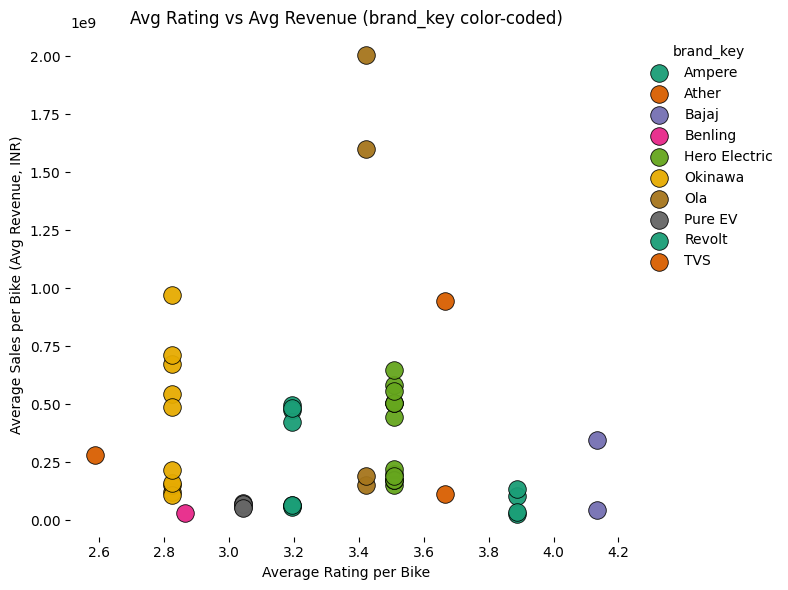

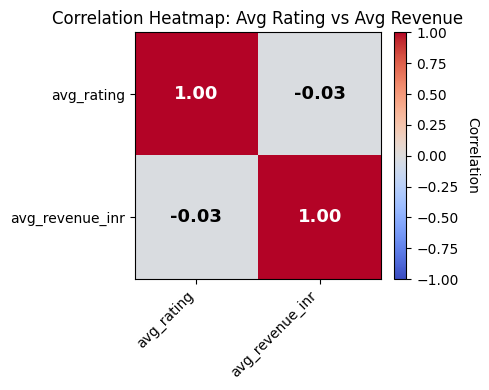

Saved to:
/content/scatter_avg_rating_vs_avg_revenue_dark_transparent.png
/content/heatmap_correlation_avg_rating_vs_avg_revenue.png


In [ ]:
# --- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- File paths
sales_path = "/content/EV2BikeWale_Sales_with_SalesDate_AND_brandkey.csv"
specs_path = "/content/EV_Models_Specs_Clean_India_NUMERIC.csv"
sent_path  = "/content/ev2_bikewale_with_sentiment_V3.csv"

# --- Load & clean
sales_df = pd.read_csv(sales_path)
specs_df = pd.read_csv(specs_path)
sent_df  = pd.read_csv(sent_path)

for df in (sales_df, specs_df, sent_df):
    df.columns = [c.strip().lower() for c in df.columns]

# sales_df has: brand_key, maker, num_vehicles, ...
# specs_df has: brand_key, model name, price (inr), ...
# sent_df  has: brand_key, rating, ...

# --- Join price and compute REVENUE = num_vehicles * price (inr)
sales_specs = sales_df.merge(
    specs_df[['brand_key','model name','price (inr)']],
    on='brand_key', how='left'
)
sales_specs['revenue_inr'] = sales_specs['num_vehicles'] * sales_specs['price (inr)']

# --- Aggregate to model level (brand_key + model), average revenue per period
agg_sales_rev = (sales_specs.groupby(['brand_key','model name','maker'], as_index=False)
                 .agg(avg_revenue_inr=('revenue_inr','mean'),
                      # keep units too if you want to compare later
                      avg_units=('num_vehicles','mean'))
                )

# --- Average rating per brand_key
agg_rating = (sent_df.groupby('brand_key', as_index=False)
              .agg(avg_rating=('rating','mean'),
                   n_reviews=('rating','size')))

# --- Combine & prep for plotting
plot_df = (agg_sales_rev.merge(agg_rating, on='brand_key', how='left')
           .rename(columns={'model name':'model_name'})
           .dropna(subset=['avg_revenue_inr','avg_rating']))

plot_df['brand_key'] = plot_df['brand_key'].astype(str)

# =========================
# 1) SCATTER (Avg Rating vs Avg Revenue) — brand_key color-coded
# =========================
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)     # transparent figure
ax.set_facecolor('none')   # transparent axes

brands = sorted(plot_df['brand_key'].unique())
cmap = plt.get_cmap('Dark2')  # dark-theme friendly qualitative palette
color_map = {b: cmap(i % cmap.N) for i, b in enumerate(brands)}

for b in brands:
    sub = plot_df[plot_df['brand_key'] == b]
    ax.scatter(
        sub['avg_rating'], sub['avg_revenue_inr'],
        s=160, marker='o', alpha=0.95,
        edgecolors='black', linewidths=0.6,
        color=color_map[b], label=b
    )

ax.set_xlabel('Average Rating per Bike')
ax.set_ylabel('Average Sales per Bike (Avg Revenue, INR)')
ax.set_title('Avg Rating vs Avg Revenue (brand_key color-coded)')

# Optional: use log scale if revenue spans many orders
# ax.set_yscale('log')

ax.legend(title='brand_key', bbox_to_anchor=(1.02, 1),
          loc='upper left', frameon=False)

# Clean “no background” look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig("/content/scatter_avg_rating_vs_avg_revenue_dark_transparent.png",
            dpi=240, transparent=True)
plt.show()

# =========================
# 2) CORRELATION HEATMAP (Avg Rating vs Avg Revenue)
# =========================
corr_df = plot_df[['avg_rating','avg_revenue_inr']].copy()
corr_matrix = corr_df.corr()  # Pearson correlation

fig2, ax2 = plt.subplots(figsize=(5,4))
im = ax2.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

# Colorbar
cbar = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Correlation', rotation=270, labelpad=15)

# Ticks/labels
ax2.set_xticks(range(corr_matrix.shape[1]))
ax2.set_yticks(range(corr_matrix.shape[0]))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax2.set_yticklabels(corr_matrix.index)

# Bold numeric labels with dynamic contrast
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.values[i, j]
        txt_color = 'white' if abs(val) > 0.5 else 'black'
        ax2.text(j, i, f"{val:.2f}", ha='center', va='center',
                 fontsize=13, fontweight='bold', color=txt_color)

ax2.set_title('Correlation Heatmap: Avg Rating vs Avg Revenue')
plt.tight_layout()
plt.savefig("/content/heatmap_correlation_avg_rating_vs_avg_revenue.png", dpi=240)
plt.show()

print("Saved to:")
print("/content/scatter_avg_rating_vs_avg_revenue_dark_transparent.png")
print("/content/heatmap_correlation_avg_rating_vs_avg_revenue.png")
